# Embedding Space Visualisation

Two complementary lenses on the same 1,189 Bible chapters:

1. **Spatial projections** (PCA, UMAP, t-SNE) — each chapter as a point in 2D, coloured by genre or book. Shows where the embedding cloud lives and whether genre structure survives compression to two dimensions.
2. **Similarity networks** — chapters or genres as nodes, edges connecting the most semantically similar pairs. Shows the relational *gravity* between parts of the Bible: which sections pull toward each other, and which chapters act as cross-genre bridges.

Three normalisation regimes are compared throughout: **Baseline**, **AbTT k=3**, and **Local genre centering**. See notebook 04 for the full treatment of normalisation techniques.

### Additional dependencies

This notebook requires two packages beyond the base environment:

```
pip install umap-learn networkx
```

In [2]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from collections import defaultdict

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

import umap
import networkx as nx

from sacred_semantics.corpus.bible import load_segments
from sacred_semantics.pipeline.embed import load as load_embeddings
from sacred_semantics.corpus.books import BOOKS

segments   = load_segments(Path('../data/processed/bible_kjv.json'))
embeddings = load_embeddings(Path('../embeddings/bible_kjv_intfloat_e5_large_v2.npy'))

print(f'Segments:   {len(segments):,}')
print(f'Embeddings: {embeddings.shape}')

Segments:   31,102
Embeddings: (31102, 1024)


## Setup: normalisation, colour palette, chapter aggregation

Normalisation functions reproduced from notebook 04 so this notebook runs standalone. The genre colour palette is defined once and reused in every plot. Three techniques are built: **Baseline** (raw embeddings), **AbTT k=3** (removes corpus mean + 2 dominant PCA directions), and **Local genre centering** (subtracts each genre's own mean).

In [3]:
# Normalisation functions

def abt_top(embs: np.ndarray, k: int) -> np.ndarray:
    mean = embs.mean(axis=0)
    centered = (embs - mean).astype(np.float64)
    n_extra = k - 1
    if n_extra > 0:
        cov = (centered.T @ centered) / len(centered)
        _, eigenvectors = np.linalg.eigh(cov)
        components = eigenvectors[:, -n_extra:].T
        proj = (centered @ components.T) @ components
        centered = centered - proj
    norms = np.linalg.norm(centered, axis=1, keepdims=True)
    return (centered / np.maximum(norms, 1e-8)).astype(np.float32)


def local_genre_center(embs: np.ndarray, segments: list) -> np.ndarray:
    result = embs.copy().astype(np.float64)
    genre_groups: dict = defaultdict(list)
    for i, s in enumerate(segments):
        genre_groups[(s['testament'], s['genre'])].append(i)
    for indices in genre_groups.values():
        result[indices] -= result[indices].mean(axis=0)
    norms = np.linalg.norm(result, axis=1, keepdims=True)
    return (result / np.maximum(norms, 1e-8)).astype(np.float32)


# Genre colour palette — shared across all plots

GENRE_ORDER = [
    ('OT', 'Pentateuch'), ('OT', 'History'), ('OT', 'Wisdom'),
    ('OT', 'Major Prophets'), ('OT', 'Minor Prophets'),
    ('NT', 'Gospel'), ('NT', 'History'), ('NT', 'Pauline Epistle'),
    ('NT', 'General Epistle'), ('NT', 'Apocalyptic'),
]
GENRE_COLORS = dict(zip(GENRE_ORDER, plt.cm.tab10.colors))


# Chapter aggregation helpers

def build_chapter_keys(segments, BOOKS):
    groups: dict = defaultdict(list)
    for i, s in enumerate(segments):
        groups[(s['book'], s['chapter'])].append(i)
    keys = [
        (book.name, ch)
        for book in BOOKS
        for ch in sorted({s['chapter'] for s in segments if s['book'] == book.name})
    ]
    return groups, keys


def chapter_embs_for(verse_embs, chapter_groups, chapter_keys):
    raw = np.stack([verse_embs[chapter_groups[k]].mean(axis=0) for k in chapter_keys])
    norms = np.linalg.norm(raw, axis=1, keepdims=True)
    return (raw / np.maximum(norms, 1e-8)).astype(np.float32)


chapter_groups, chapter_keys = build_chapter_keys(segments, BOOKS)

# Chapter-level metadata — use first verse in each chapter
first_seg = {}
for s in segments:
    k = (s['book'], s['chapter'])
    if k not in first_seg:
        first_seg[k] = s

chap_genre     = [(first_seg[k]['testament'], first_seg[k]['genre']) for k in chapter_keys]
chap_testament = [first_seg[k]['testament'] for k in chapter_keys]
chap_book_arr  = np.array([k[0] for k in chapter_keys])

# Build chapter embeddings for three techniques
TECHNIQUES = {
    'Baseline':    embeddings,
    'AbTT k=3':   abt_top(embeddings, k=3),
    'Local genre': local_genre_center(embeddings, segments),
}

chap_embs = {}
for name, ve in TECHNIQUES.items():
    chap_embs[name] = chapter_embs_for(ve, chapter_groups, chapter_keys)
    print(f'{name:<14}  {chap_embs[name].shape}')

print()
print(f'{len(chapter_keys):,} chapters total')

Baseline        (1189, 1024)
AbTT k=3        (1189, 1024)
Local genre     (1189, 1024)

1,189 chapters total


## 1. PCA — a first look

PCA finds the two directions of greatest variance in the 1,024-dimensional space and projects every chapter onto them. Fast and deterministic, making it a useful sanity-check before the slower non-linear methods.

Because only two of 1,024 dimensions are kept, most variance is discarded — the percentage captured appears in each panel title. Cluster structure that survives PCA is almost certainly real; absence in PCA does not mean absence in the full space.

The first plot colours points by genre (10 categories); the second strips that away and shows only the OT/NT split to test whether the two testaments form a large-scale separation.

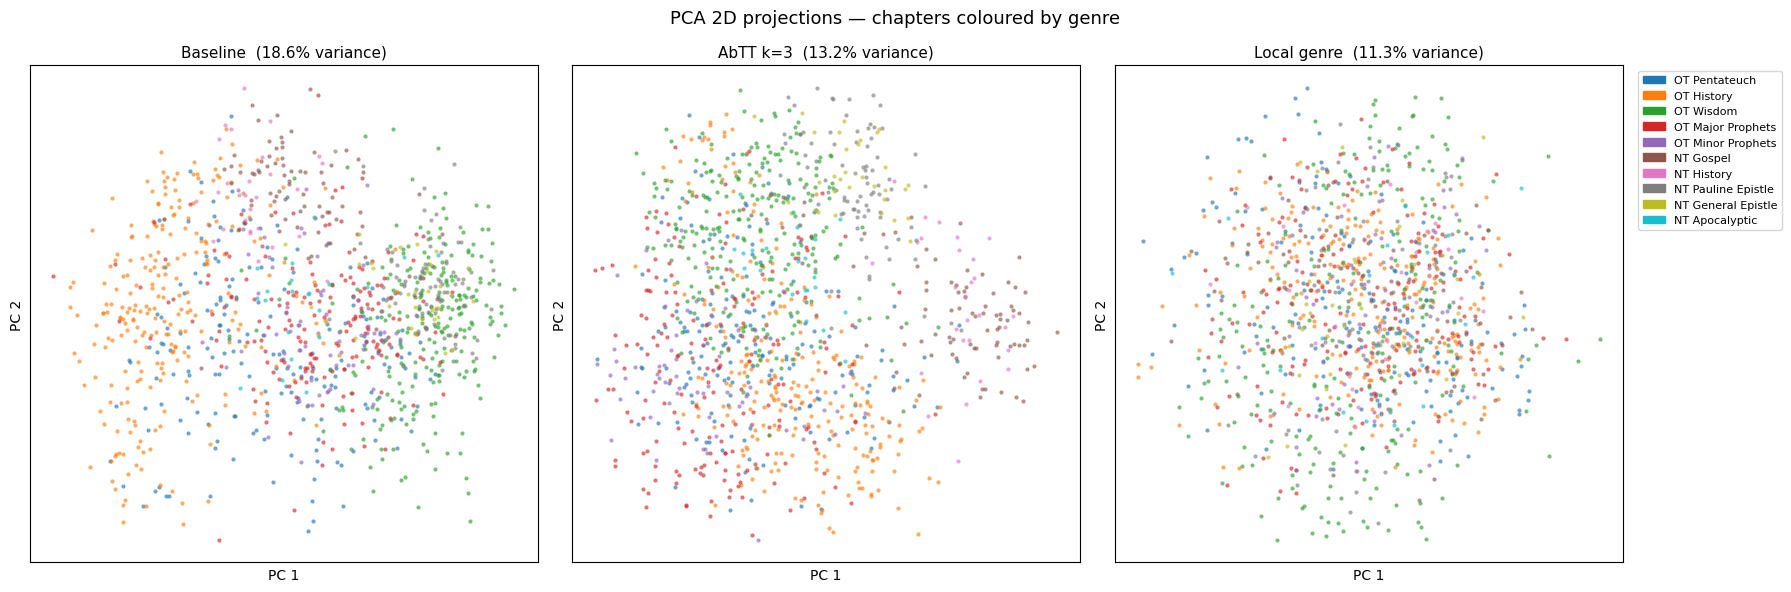

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (name, ce) in zip(axes, chap_embs.items()):
    pca = PCA(n_components=2, random_state=42)
    coords = pca.fit_transform(ce)
    for genre in GENRE_ORDER:
        mask = np.array([g == genre for g in chap_genre])
        ax.scatter(coords[mask, 0], coords[mask, 1],
                   color=GENRE_COLORS[genre], s=9, alpha=0.65, linewidths=0)
    var = pca.explained_variance_ratio_.sum() * 100
    ax.set_title(f'{name}  ({var:.1f}% variance)', fontsize=11)
    ax.set_xlabel('PC 1')
    ax.set_ylabel('PC 2')
    ax.set_xticks([])
    ax.set_yticks([])

handles = [mpatches.Patch(color=GENRE_COLORS[g], label=f'{g[0]} {g[1]}') for g in GENRE_ORDER]
axes[-1].legend(handles=handles, bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
fig.suptitle('PCA 2D projections — chapters coloured by genre', fontsize=13)
plt.tight_layout()
plt.show()

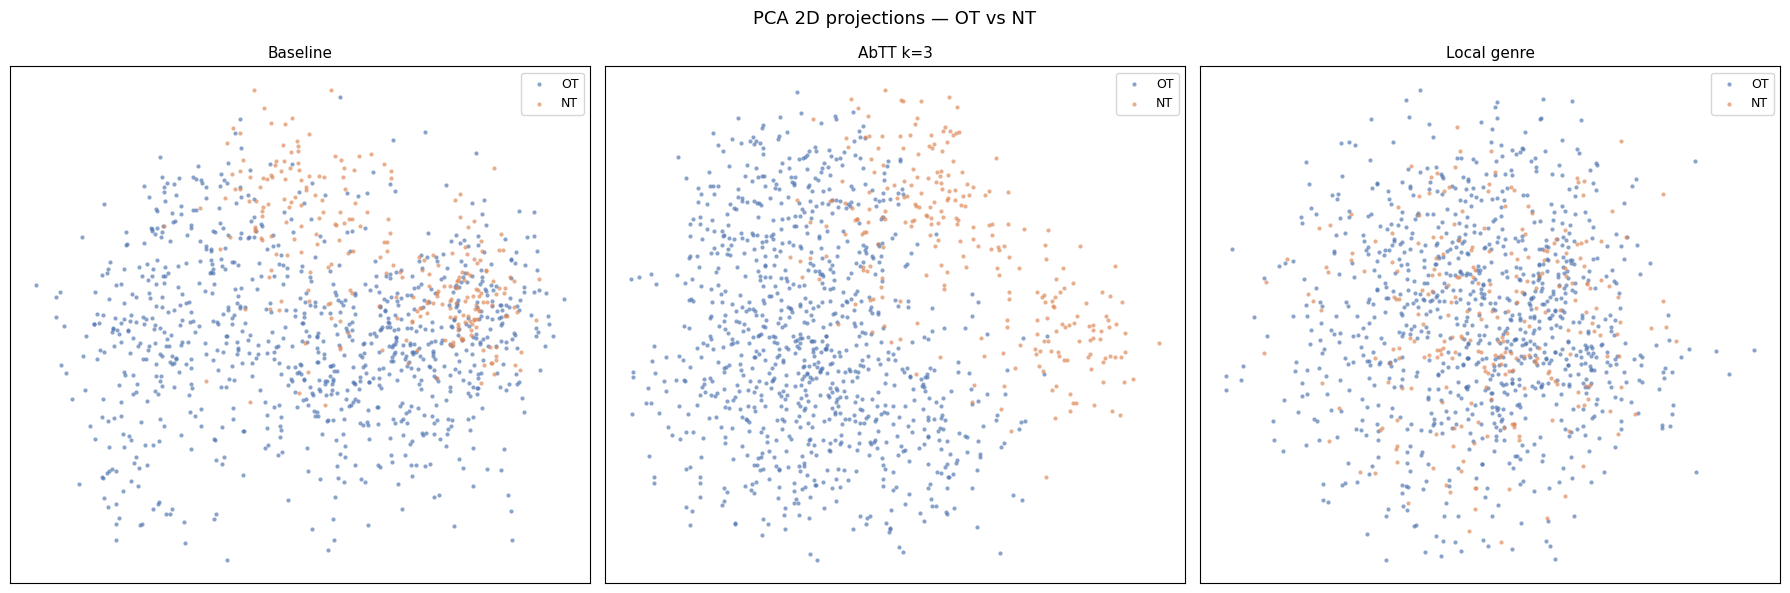

In [5]:
TESTAMENT_COLORS = {'OT': '#4C72B0', 'NT': '#DD8452'}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, (name, ce) in zip(axes, chap_embs.items()):
    pca = PCA(n_components=2, random_state=42)
    coords = pca.fit_transform(ce)
    for testament, color in TESTAMENT_COLORS.items():
        mask = np.array([t == testament for t in chap_testament])
        ax.scatter(coords[mask, 0], coords[mask, 1],
                   color=color, s=9, alpha=0.65, linewidths=0, label=testament)
    ax.set_title(name, fontsize=11)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.legend(fontsize=9)

fig.suptitle('PCA 2D projections — OT vs NT', fontsize=13)
plt.tight_layout()
plt.show()

## 2. UMAP projections

UMAP (Uniform Manifold Approximation and Projection) is a non-linear method that preserves the *local* neighbourhood structure of the data: chapters near each other in 1,024-dimensional space appear close in 2D. Unlike PCA, UMAP can bend and fold the space to reveal clusters along curved manifolds, at the cost of making global distances less interpretable.

Key parameters:
- `n_neighbors=15` — neighbourhood size for the local graph. Smaller values emphasise tight clusters; larger values give more global structure.
- `min_dist=0.1` — how tightly points pack. 0.1 gives visible separation without over-compressing.
- `metric='cosine'` — consistent with how similarity is measured throughout the project.

Each technique is fit independently: absolute positions are not comparable across panels. Only the *shape* of each cloud matters.

The second plot colours the same AbTT k=3 projection by individual book (66 colours in canonical order) to show where each book's chapters land relative to the whole.

In [6]:
umap_coords = {}
for name, ce in chap_embs.items():
    reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1,
                        metric='cosine', random_state=42)
    umap_coords[name] = reducer.fit_transform(ce)
    print(f'{name:<14}  done')

l:\Github Repos\Semantic-Embeddings\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Baseline        done


l:\Github Repos\Semantic-Embeddings\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


AbTT k=3        done


l:\Github Repos\Semantic-Embeddings\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Local genre     done


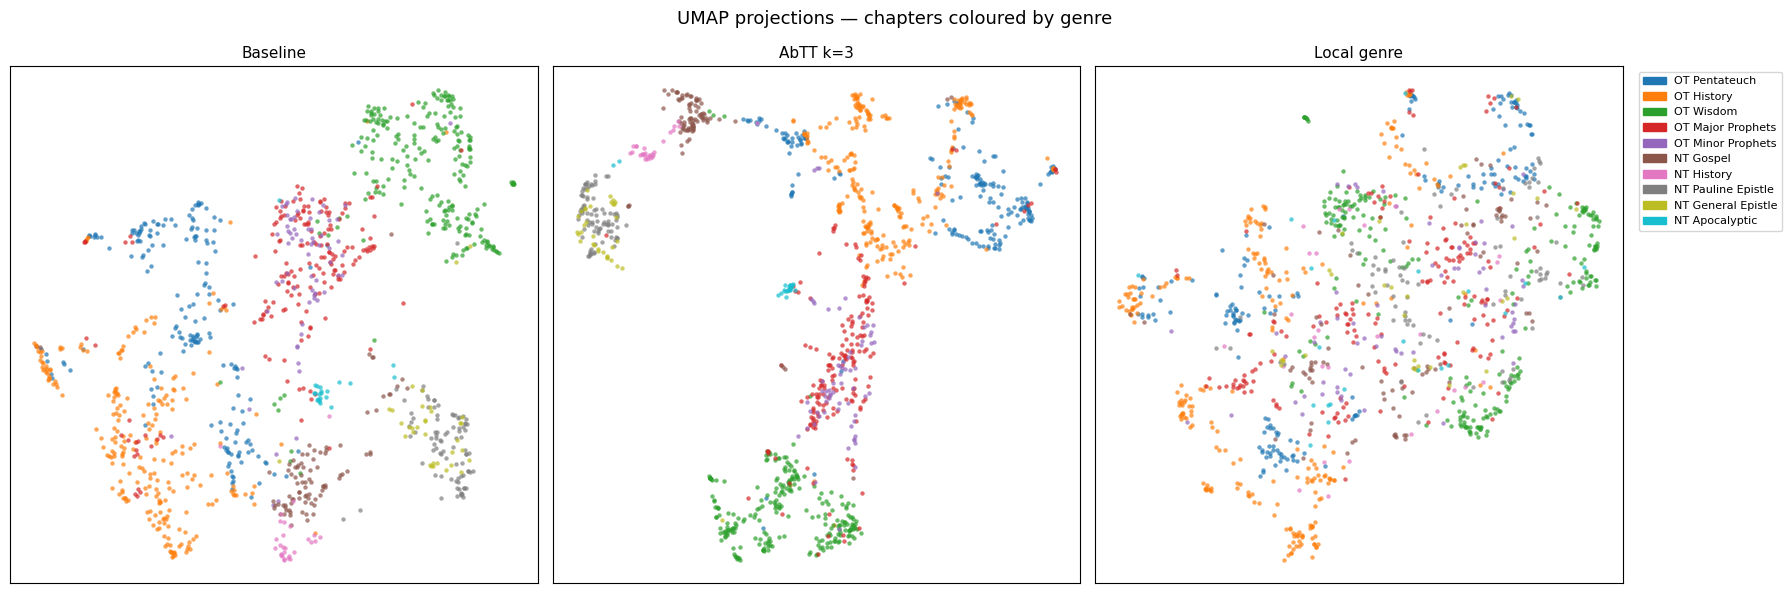

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (name, coords) in zip(axes, umap_coords.items()):
    for genre in GENRE_ORDER:
        mask = np.array([g == genre for g in chap_genre])
        ax.scatter(coords[mask, 0], coords[mask, 1],
                   color=GENRE_COLORS[genre], s=10, alpha=0.7, linewidths=0)
    ax.set_title(name, fontsize=11)
    ax.set_xticks([])
    ax.set_yticks([])

handles = [mpatches.Patch(color=GENRE_COLORS[g], label=f'{g[0]} {g[1]}') for g in GENRE_ORDER]
axes[-1].legend(handles=handles, bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
fig.suptitle('UMAP projections — chapters coloured by genre', fontsize=13)
plt.tight_layout()
plt.show()

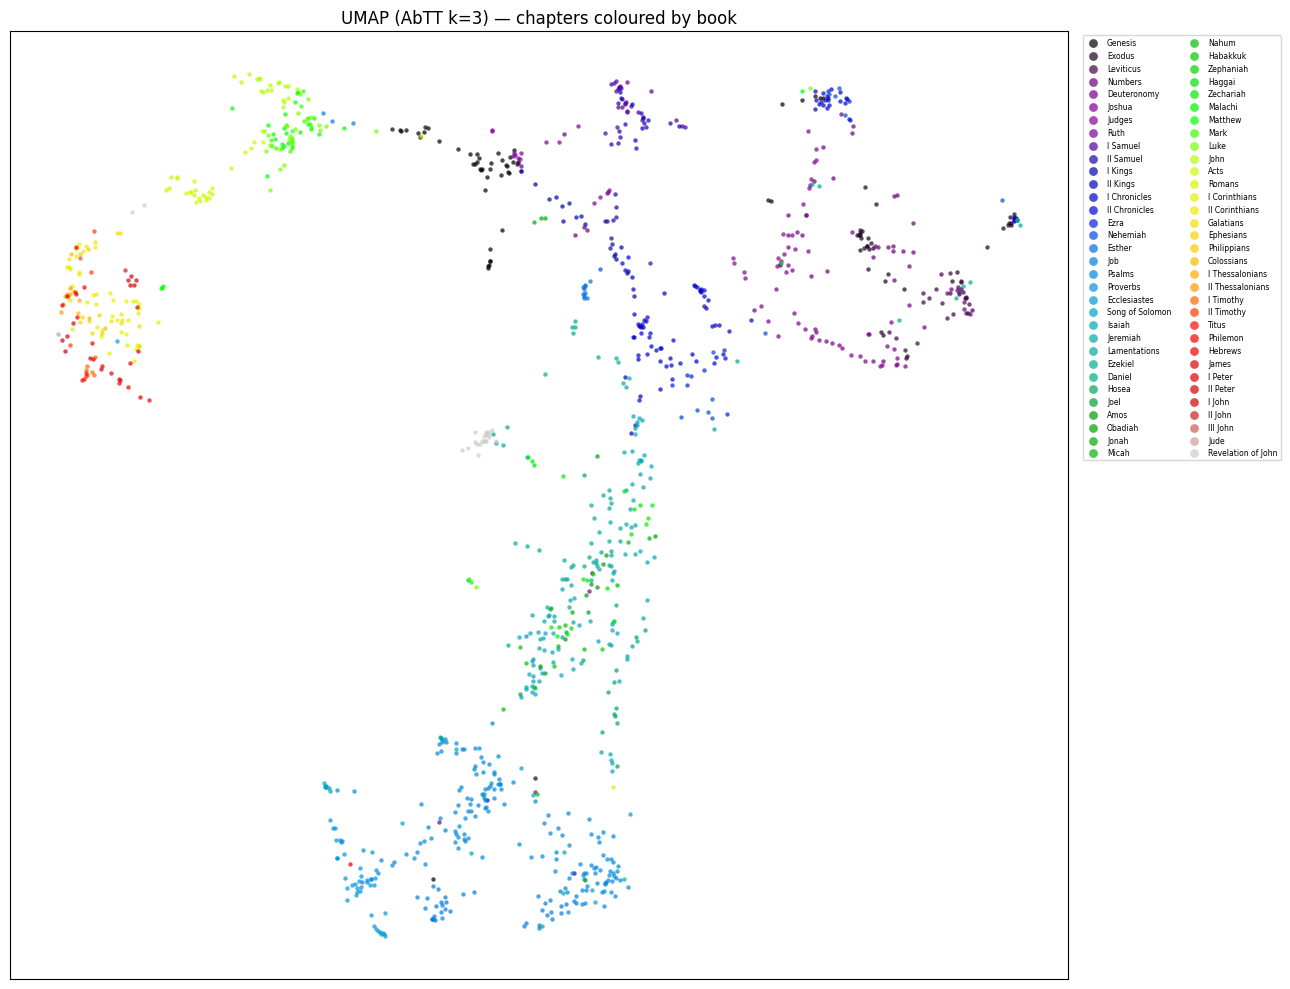

In [8]:
book_names_ordered = [b.name for b in BOOKS]
book_colors = {name: plt.cm.nipy_spectral(i / (len(book_names_ordered) - 1))
               for i, name in enumerate(book_names_ordered)}

coords = umap_coords['AbTT k=3']
fig, ax = plt.subplots(figsize=(13, 10))
for book in book_names_ordered:
    mask = chap_book_arr == book
    ax.scatter(coords[mask, 0], coords[mask, 1],
               color=book_colors[book], s=10, alpha=0.7, linewidths=0, label=book)

ax.set_title('UMAP (AbTT k=3) — chapters coloured by book', fontsize=12)
ax.set_xticks([])
ax.set_yticks([])
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=5.5, ncol=2, markerscale=2)
plt.tight_layout()
plt.show()

## 3. t-SNE projection

t-SNE is a slower non-linear method that tends to produce tighter, more visually separated clusters than UMAP, at the cost of compressing long-range relationships — two distant clusters in t-SNE may or may not reflect genuine global distance.

Only `AbTT k=3` is shown here for direct comparison with the UMAP view above. Parameters: `perplexity=40` (a reasonable neighbourhood size for 1,189 chapters) and `n_iter=1000`.

In [9]:
tsne = TSNE(n_components=2, perplexity=40, n_iter=1000, metric='cosine',
            random_state=42, verbose=1)
tsne_coords = tsne.fit_transform(chap_embs['AbTT k=3'])

fig, ax = plt.subplots(figsize=(10, 8))
for genre in GENRE_ORDER:
    mask = np.array([g == genre for g in chap_genre])
    ax.scatter(tsne_coords[mask, 0], tsne_coords[mask, 1],
               color=GENRE_COLORS[genre], s=12, alpha=0.75, linewidths=0)

handles = [mpatches.Patch(color=GENRE_COLORS[g], label=f'{g[0]} {g[1]}') for g in GENRE_ORDER]
ax.legend(handles=handles, bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
ax.set_title('t-SNE (AbTT k=3) — chapters coloured by genre', fontsize=12)
ax.set_xticks([])
ax.set_yticks([])
plt.tight_layout()
plt.show()

TypeError: TSNE.__init__() got an unexpected keyword argument 'n_iter'

## 4. Similarity networks

Projections show *where* chapters live in reduced space. Networks show *how* they are connected by similarity. Two scales:

**Genre network (10 nodes):** Each node is a genre; edge width is proportional to mean inter-genre cosine similarity (AbTT k=3). The macro view — which broad regions of the Bible attract each other?

**Chapter network (1,189 nodes):** Each node is a chapter; an edge is drawn only if one chapter falls among the top-K most similar chapters to another *in a different book* (within-book edges are excluded to surface cross-book bridges). Node size reflects degree — larger nodes are semantic hubs cited by many other chapters.

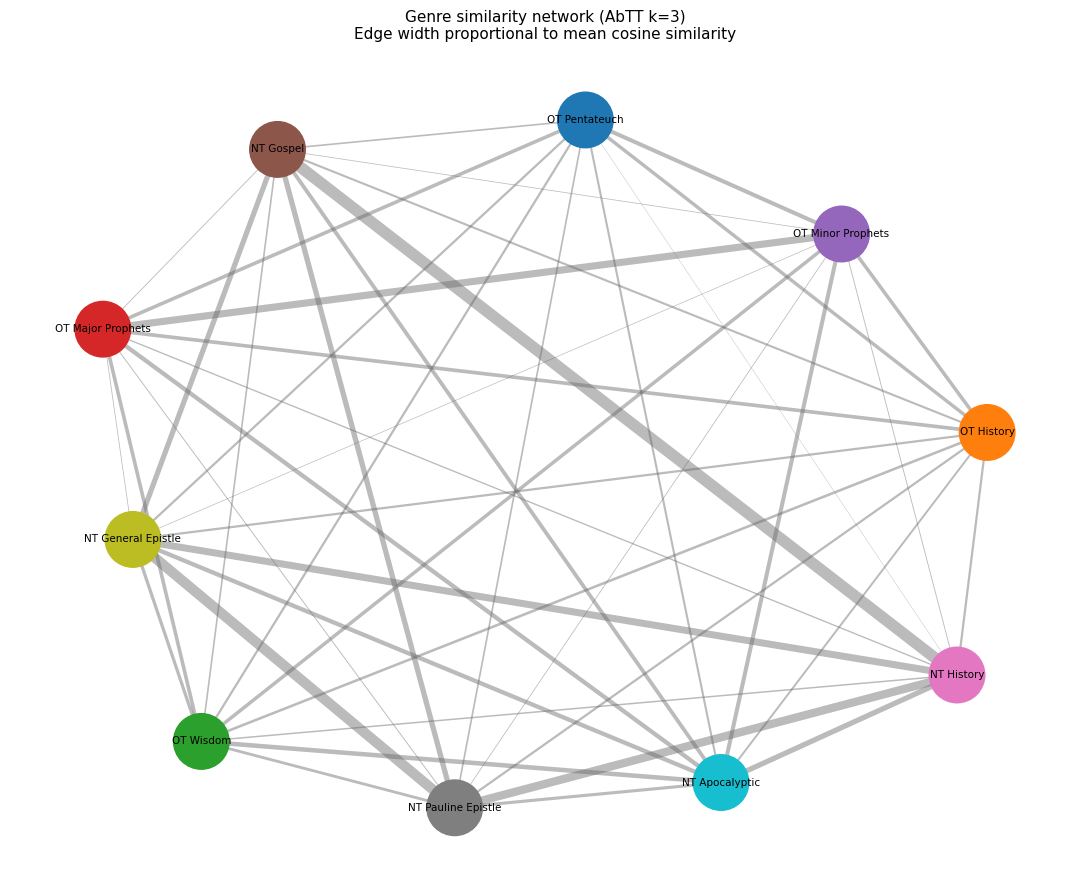

Strongest inter-genre connections:
Genre A                    Genre B                    Similarity
----------------------------------------------------------------
NT Gospel                  NT History                     0.2377
NT Pauline Epistle         NT General Epistle             0.1993
NT History                 NT Pauline Epistle             0.1407
OT Major Prophets          OT Minor Prophets              0.1082
NT History                 NT General Epistle             0.1045
NT Gospel                  NT Pauline Epistle             0.0544
NT History                 NT Apocalyptic                 0.0529
NT Gospel                  NT General Epistle             0.0511
OT Wisdom                  NT Apocalyptic                 0.0315
NT General Epistle         NT Apocalyptic                 0.0244


In [10]:
# Genre-level similarity matrix from chapter embeddings
ce = chap_embs['AbTT k=3']
sim_mat = ce @ ce.T

genre_to_ch_idx = defaultdict(list)
for i, g in enumerate(chap_genre):
    genre_to_ch_idx[g].append(i)

n_genres = len(GENRE_ORDER)
genre_sim = np.zeros((n_genres, n_genres))
for i, gi in enumerate(GENRE_ORDER):
    for j, gj in enumerate(GENRE_ORDER):
        block = sim_mat[np.ix_(genre_to_ch_idx[gi], genre_to_ch_idx[gj])]
        genre_sim[i, j] = block.mean()

# Build graph — fully connected, weighted by similarity
G_genre = nx.Graph()
for i in range(n_genres):
    G_genre.add_node(i)
for i in range(n_genres):
    for j in range(i + 1, n_genres):
        G_genre.add_edge(i, j, weight=float(genre_sim[i, j]))

pos = nx.spring_layout(G_genre, weight='weight', seed=42, k=2.5)
node_colors = [GENRE_COLORS[GENRE_ORDER[i]] for i in range(n_genres)]
labels = {i: GENRE_ORDER[i][0] + ' ' + GENRE_ORDER[i][1] for i in range(n_genres)}

weights    = np.array([d['weight'] for _, _, d in G_genre.edges(data=True)])
w_norm     = (weights - weights.min()) / (weights.max() - weights.min())
edge_widths = 0.3 + w_norm * 8.0

fig, ax = plt.subplots(figsize=(11, 9))
nx.draw_networkx_nodes(G_genre, pos, node_color=node_colors, node_size=1600, ax=ax)
nx.draw_networkx_labels(G_genre, pos, labels=labels, font_size=7.5, ax=ax)
nx.draw_networkx_edges(G_genre, pos, width=edge_widths, alpha=0.45,
                       edge_color='dimgrey', ax=ax)
ax.set_title(
    'Genre similarity network (AbTT k=3)\nEdge width proportional to mean cosine similarity',
    fontsize=11
)
ax.axis('off')
plt.tight_layout()
plt.show()

print('Strongest inter-genre connections:')
print('{:<26} {:<26} {:>10}'.format('Genre A', 'Genre B', 'Similarity'))
print('-' * 64)
edges_ranked = sorted(
    [(i, j, genre_sim[i, j]) for i in range(n_genres) for j in range(i + 1, n_genres)],
    key=lambda x: -x[2]
)
for i, j, val in edges_ranked[:10]:
    ga = GENRE_ORDER[i][0] + ' ' + GENRE_ORDER[i][1]
    gb = GENRE_ORDER[j][0] + ' ' + GENRE_ORDER[j][1]
    print(f'{ga:<26} {gb:<26} {val:>10.4f}')

Nodes: 1,189
Edges: 2,948
Computing spring layout (30–90 s on CPU)...


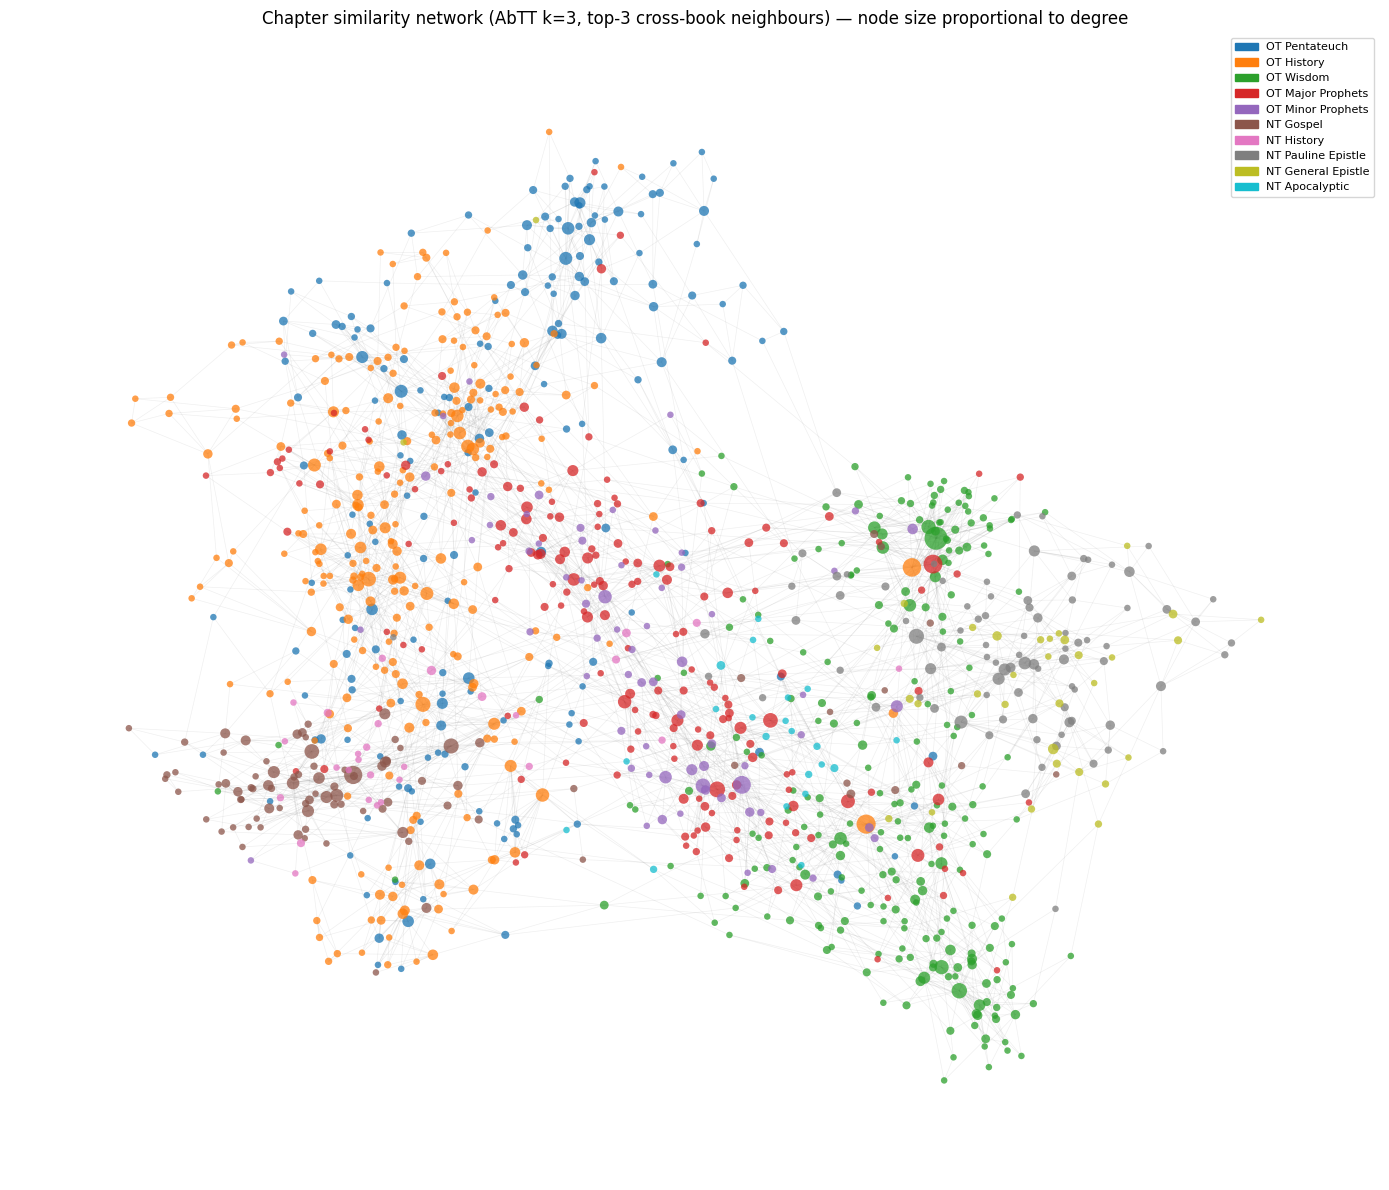

Top 20 semantic hubs:
Rank  Chapter                        Genre                          Degree
-------------------------------------------------------------------------
1     Job 30                         OT Wisdom                          45
2     I Chronicles 16                OT History                         31
3     Lamentations 3                 OT Major Prophets                  30
4     II Samuel 22                   OT History                         29
5     Luke 9                         NT Gospel                          28
6     Joel 2                         OT Minor Prophets                  27
7     Isaiah 13                      OT Major Prophets                  21
8     Ecclesiastes 10                OT Wisdom                          20
9     II Kings 4                     OT History                         19
10    Luke 24                        NT Gospel                          19
11    I Thessalonians 2              NT Pauline Epistle                 19
12  

In [11]:
ce       = chap_embs['AbTT k=3']
chap_sim = (ce @ ce.T).astype(np.float64)

TOP_K = 3  # cross-book neighbours per chapter

G_chap = nx.Graph()
for i in range(len(chapter_keys)):
    G_chap.add_node(i)

for i in range(len(chapter_keys)):
    scores = chap_sim[i].copy()
    scores[chap_book_arr == chap_book_arr[i]] = -np.inf
    scores[i] = -np.inf
    top_idx = np.argsort(scores)[-TOP_K:]
    for j in top_idx:
        if not np.isinf(scores[j]):
            G_chap.add_edge(i, j, weight=float(scores[j]))

print(f'Nodes: {G_chap.number_of_nodes():,}')
print(f'Edges: {G_chap.number_of_edges():,}')

print('Computing spring layout (30–90 s on CPU)...')
pos_chap = nx.spring_layout(G_chap, weight='weight', seed=42, k=0.25, iterations=50)

node_cols  = [GENRE_COLORS[chap_genre[i]] for i in G_chap.nodes()]
degrees    = np.array([G_chap.degree(i) for i in G_chap.nodes()])
node_sizes = 4 + degrees * 6

fig, ax = plt.subplots(figsize=(14, 12))
nx.draw_networkx_nodes(G_chap, pos_chap, node_color=node_cols,
                       node_size=node_sizes, alpha=0.75, ax=ax, linewidths=0)
nx.draw_networkx_edges(G_chap, pos_chap, alpha=0.12, edge_color='grey', width=0.5, ax=ax)

handles = [mpatches.Patch(color=GENRE_COLORS[g], label=f'{g[0]} {g[1]}') for g in GENRE_ORDER]
ax.legend(handles=handles, loc='upper right', fontsize=8)
ax.set_title(
    'Chapter similarity network (AbTT k=3, top-' + str(TOP_K) + ' cross-book neighbours)'
    ' — node size proportional to degree',
    fontsize=12
)
ax.axis('off')
plt.tight_layout()
plt.show()

print('Top 20 semantic hubs:')
print('{:<5} {:<30} {:<30} {:>6}'.format('Rank', 'Chapter', 'Genre', 'Degree'))
print('-' * 73)
for rank, (i, deg) in enumerate(sorted(G_chap.degree(), key=lambda x: -x[1])[:20], 1):
    book, ch = chapter_keys[i]
    g = chap_genre[i]
    print(f'{rank:<5} {book + " " + str(ch):<30} {g[0] + " " + g[1]:<30} {deg:>6}')

## 5. Interactive HTML exports

The cells below rebuild the networks and UMAP projections as self-contained HTML files saved to `../outputs/`. Open them in any browser — no server needed.

| File | What it shows |
|---|---|
| `umap_baseline_genre.html` | Baseline UMAP, hover shows chapter + genre |
| `umap_abttk3_genre.html` | AbTT k=3 UMAP, hover shows chapter + genre |
| `umap_localgenre_genre.html` | Local genre UMAP, hover shows chapter + genre |
| `genre_network_interactive.html` | 10-node genre graph, hover shows similarity details |
| `chapter_network_interactive.html` | 1,189-node chapter graph, hover shows book/chapter/connections |

**Additional dependencies:**
```
pip install plotly pyvis
```

All layouts are pre-computed in Python so the browser just renders — no physics simulation lag.

In [12]:
import plotly.graph_objects as go
from pyvis.network import Network

outputs_dir = Path('../outputs')
outputs_dir.mkdir(exist_ok=True)
print(f'Output directory: {outputs_dir.resolve()}')

Output directory: L:\Github Repos\Semantic-Embeddings\outputs


In [13]:
def _hex(genre):
    r, g, b = (int(c * 255) for c in GENRE_COLORS[genre][:3])
    return f'#{r:02x}{g:02x}{b:02x}'

def _rgba(genre, alpha=0.75):
    r, g, b = (int(c * 255) for c in GENRE_COLORS[genre][:3])
    return f'rgba({r},{g},{b},{alpha})'

# One HTML file per UMAP technique
technique_slugs = {
    'Baseline':    'baseline',
    'AbTT k=3':   'abttk3',
    'Local genre': 'localgenre',
}

for technique_name, coords in umap_coords.items():
    fig = go.Figure()
    for genre in GENRE_ORDER:
        idx = np.where(np.array([g == genre for g in chap_genre]))[0]
        genre_label = genre[0] + ' ' + genre[1]
        hover = [
            f'<b>{chapter_keys[i][0]} {chapter_keys[i][1]}</b>'
            f'<br>Genre: {genre_label}'
            f'<br>Testament: {chap_testament[i]}'
            for i in idx
        ]
        fig.add_trace(go.Scatter(
            x=coords[idx, 0],
            y=coords[idx, 1],
            mode='markers',
            name=genre_label,
            text=hover,
            hovertemplate='%{text}<extra></extra>',
            marker=dict(size=5, color=_rgba(genre, 0.8)),
        ))

    fig.update_layout(
        title=dict(text=f'UMAP — {technique_name} (hover for chapter details)', font_size=15),
        xaxis=dict(showticklabels=False, showgrid=False, zeroline=False, title=''),
        yaxis=dict(showticklabels=False, showgrid=False, zeroline=False, title=''),
        legend=dict(itemsizing='constant', font_size=11),
        width=1100, height=720,
        plot_bgcolor='white',
    )

    slug = technique_slugs[technique_name]
    out = outputs_dir / f'umap_{slug}_genre.html'
    fig.write_html(str(out), include_plotlyjs='cdn')
    print(f'Saved  {out}')

Saved  ..\outputs\umap_baseline_genre.html
Saved  ..\outputs\umap_abttk3_genre.html
Saved  ..\outputs\umap_localgenre_genre.html


In [14]:
# Interactive genre network — 10 nodes, edge width = similarity
net_genre = Network(height='700px', width='100%', bgcolor='#f8f8f8', font_color='#111111')
net_genre.toggle_physics(False)

scale = 450
for i in range(n_genres):
    g = GENRE_ORDER[i]
    n_ch = len(genre_to_ch_idx[g])
    top3 = sorted(
        [(j, genre_sim[i, j]) for j in range(n_genres) if j != i],
        key=lambda t: -t[1]
    )[:3]
    top_str = '<br>'.join(
        f'{GENRE_ORDER[j][0]} {GENRE_ORDER[j][1]}: {v:.4f}' for j, v in top3
    )
    title_html = (
        f'<b>{g[0]} {g[1]}</b><br>'
        f'{n_ch} chapters<br><br>'
        f'Most similar genres:<br>{top_str}'
    )
    x, y = pos[i]
    net_genre.add_node(
        i,
        label=g[0] + ' ' + g[1],
        title=title_html,
        x=float(x * scale),
        y=float(-y * scale),
        color=_hex(g),
        size=30,
        font={'size': 13},
    )

for u, v, d in G_genre.edges(data=True):
    w = float(d['weight'])
    wn = (w - float(weights.min())) / (float(weights.max()) - float(weights.min()))
    net_genre.add_edge(
        u, v,
        width=0.3 + wn * 9.0,
        title=f'Similarity: {w:.4f}',
        color='rgba(100,100,100,0.55)',
    )

out_genre = outputs_dir / 'genre_network_interactive.html'
net_genre.write_html(str(out_genre))
print(f'Saved  {out_genre}')

Saved  ..\outputs\genre_network_interactive.html


In [15]:
# Interactive chapter network — 1,189 nodes, positions from spring layout
# Physics is disabled; layout was already computed in cell above so the
# browser just renders it without any simulation lag.
net_chap = Network(height='900px', width='100%', bgcolor='#12121f', font_color='white')
net_chap.toggle_physics(False)

scale_ch = 1500
for i in G_chap.nodes():
    g = chap_genre[i]
    book, ch = chapter_keys[i]
    deg = G_chap.degree(i)
    x, y = pos_chap[i]
    neighbors_preview = ', '.join(
        f'{chapter_keys[j][0]} {chapter_keys[j][1]}' for j in list(G_chap.neighbors(i))[:6]
    )
    title_html = (
        f'<b>{book} {ch}</b><br>'
        f'Genre: {g[0]} {g[1]}<br>'
        f'Testament: {chap_testament[i]}<br>'
        f'Degree: {deg}<br>'
        f'Connected to: {neighbors_preview}'
    )
    net_chap.add_node(
        i,
        label='',
        title=title_html,
        x=float(x * scale_ch),
        y=float(-y * scale_ch),
        color=_hex(g),
        size=max(3, 3 + deg * 2.5),
    )

for u, v, d in G_chap.edges(data=True):
    net_chap.add_edge(u, v, width=0.4, color='rgba(180,180,180,0.12)')

out_chap = outputs_dir / 'chapter_network_interactive.html'
net_chap.write_html(str(out_chap))
print(f'Saved  {out_chap}')
print('Tip: the file is ~3-5 MB; give the browser a moment to render all nodes.')

TypeError: Object of type int64 is not JSON serializable